In [24]:
# --- 필요한 라이브러리 불러오기 ---
import os
import json
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [28]:
# ==============================================================================
# ✨ 헬퍼 함수 1: 검증 데이터 로드 ✨
# ==============================================================================
def load_validation_data(normal_path, phishing_path):
    """
    [함수 기능]
    검증 데이터 폴더(val_data)에서 모든 json 파일을 읽어와,
    'text'와 실제 정답인 'label'을 가진 표(DataFrame)로 만들어 반환합니다.
    
    [파라미터 설명]
    - normal_path (str): 일반 통화 json 파일들이 들어있는 폴더 경로
    - phishing_path (str): 보이스피싱 json 파일들이 들어있는 폴더 경로
    
    [사용 목적]
    학습 때 사용했던 데이터 로딩 로직과 동일한 방식으로, 
    모델 성능 평가에 사용할 데이터를 준비하기 위해 작성되었습니다.
    """
    data_list = []

    # 1. 일반 통화 데이터 처리 (정답 label=0)
    for filename in os.listdir(normal_path):
        if filename.endswith(".json"):
            file_path = os.path.join(normal_path, filename)
            with open(file_path, 'r', encoding='utf-8') as f:
                json_data = json.load(f)
            
            dialogs = json_data['dataSet']['dialogs']
            conversation_parts = [dialog['text'] for dialog in dialogs]
            full_conversation = " ".join(conversation_parts)
            data_list.append({'text': full_conversation, 'label': 0})

    # 2. 보이스피싱 데이터 처리 (정답 label=1)
    for filename in os.listdir(phishing_path):
        if filename.endswith(".json"):
            file_path = os.path.join(phishing_path, filename)
            with open(file_path, 'r', encoding='utf-8') as f:
                json_data = json.load(f)

            full_conversation = json_data['text']
            data_list.append({'text': full_conversation, 'label': 1})

    return pd.DataFrame(data_list)
   

In [29]:
# ==============================================================================
# ✨ 헬퍼 함수 2: 상세 예측 결과 반환 ✨
# (test_model.py의 기능을 가져온 함수)
# ==============================================================================
def get_detailed_prediction(model, tokenizer, sentence):
    """
    [함수 기능]
    주어진 문장 하나에 대해, 모델의 예측 라벨과 각 라벨에 대한 확률을 상세히 반환합니다.
    [파라미터 설명]
    - model: 예측을 수행할 파인튜닝된 모델
    - tokenizer: 문장을 숫자로 변환할 토크나이저
    - sentence (str): 예측을 원하는 단일 문장 (전체 통화 내용)
    [사용 목적]
    모델이 특정 샘플에 대해 '왜' 그렇게 판단했는지 확률을 통해 직관적으로 보여주기 위함입니다.
    """
    inputs = tokenizer(sentence, return_tensors="pt", padding=True, truncation=True, max_length=512)
    
    with torch.no_grad():
        logits = model(**inputs).logits
        
    probabilities = torch.nn.functional.softmax(logits, dim=-1)[0]
    predicted_label_id = torch.argmax(logits, dim=-1).item()
    
    return {
        "predicted_id": predicted_label_id,
        "predicted_label": "보이스피싱" if predicted_label_id == 1 else "일반 대화",
        "phishing_probability": probabilities[1].item() * 100
    }


In [30]:
def get_prediction(model, tokenizer, sentence):
    """
    [함수 기능]
    모델과 토크나이저를 이용해, 주어진 문장 하나에 대한 예측 결과(0 또는 1)를 반환합니다.
    
    [파라미터 설명]
    - model: 예측을 수행할 파인튜닝된 모델
    - tokenizer: 문장을 숫자로 변환할 토크나이저
    - sentence (str): 예측을 원하는 단일 문장 (전체 통화 내용)

    [사용 목적]
    검증 데이터셋의 모든 문장에 대해 반복적으로 예측을 수행하고, 
    그 결과를 실제 정답과 비교하기 위해 사용됩니다.
    """
    inputs = tokenizer(sentence, return_tensors="pt", padding=True, truncation=True, max_length=512)
    
    with torch.no_grad():
        logits = model(**inputs).logits

    # 모델의 출력값(logits) 중 가장 높은 값의 인덱스를 예측 결과로 선택
    # 예를 들어 [0.1, 0.9] 라면 0.9가 더 높으므로 인덱스 1을 반환 (보이스피싱)
    prediction = torch.argmax(logits, dim=-1).item()
    return prediction

--- 1. 검증 데이터와 파인튜닝된 모델을 불러옵니다. ---
총 16개의 검증 데이터 로드 완료.

--- 2. 전체 검증 데이터로 모델 성능을 평가합니다. (for Confusion Matrix) ---

--- 3. 평가 결과를 바탕으로 혼동 행렬을 생성합니다. ---


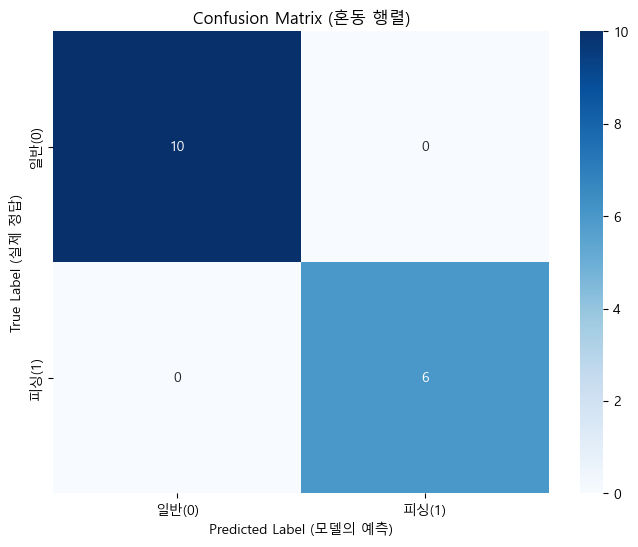


--- 4. 개별 샘플에 대한 상세 예측 결과를 확인합니다. ---

샘플 1 / 실제 정답: '일반 대화'
문장 (앞 50자): 여기 그 사탐 선택 좀 (여쭤보려)/(여쭤볼려) 그러는데요. 예 저기 그 지금 그 홈페이지...
---------------------------------------------
모델의 판단: '일반 대화'
보이스피싱일 확률: 0.01%

샘플 2 / 실제 정답: '일반 대화'
문장 (앞 50자): 아 학습 지원 센터하면 바로 상담이 가능한 건가요? 아 네, 네, 혹시 어떤 부분 때문에 ...
---------------------------------------------
모델의 판단: '일반 대화'
보이스피싱일 확률: 0.01%

샘플 3 / 실제 정답: '일반 대화'
문장 (앞 50자): 아 여기 그 유수 고 (2)/(이) (고요)/(구요). 네, 안들리세요? 어 혹시 지금 잠...
---------------------------------------------
모델의 판단: '일반 대화'
보이스피싱일 확률: 0.01%

샘플 4 / 실제 정답: '일반 대화'
문장 (앞 50자): 한국사를 더 추가하게 되면은 비용이 어떻게 되고 전과목을 하게 되면 어떻게 되는지 그냥 혹...
---------------------------------------------
모델의 판단: '일반 대화'
보이스피싱일 확률: 0.01%

샘플 5 / 실제 정답: '일반 대화'
문장 (앞 50자): 네, 안녕하십니까? 무엇을 도와드릴까요? 예, 그 고 (2)/(이)인데 어 네, 이거를 어...
---------------------------------------------
모델의 판단: '일반 대화'
보이스피싱일 확률: 0.01%

샘플 6 / 실제 정답: '일반 대화'
문장 (앞 50자): 학습 지원 센터입니다. 무엇을 도와드릴까요? 어 소개받고서 지금 처음 신청을 하려고 하는데...
--------------------------------

In [32]:
# ==============================================================================
# ✨ 메인 실행 부분 ✨
# ==============================================================================
if __name__ == "__main__":
    
    # --- 1. 검증 데이터 및 모델 로드 ---
    print("--- 1. 검증 데이터와 파인튜닝된 모델을 불러옵니다. ---")
    val_normal_dir = "C:/phishing_project/val_data/normal"
    val_phishing_dir = "C:/phishing_project/val_data/phishing"
    val_df = load_validation_data(val_normal_dir, val_phishing_dir)
    
    fine_tuned_model_path = "./fine-tuned-phishing-model"
    tokenizer = AutoTokenizer.from_pretrained(fine_tuned_model_path)
    model = AutoModelForSequenceClassification.from_pretrained(fine_tuned_model_path)
    model.eval() # 모델을 평가 모드로 설정
    
    print(f"총 {len(val_df)}개의 검증 데이터 로드 완료.")

    # --- 2. 전체 검증 데이터에 대한 예측 수행 (혼동 행렬용) ---
    print("\n--- 2. 전체 검증 데이터로 모델 성능을 평가합니다. (for Confusion Matrix) ---")
    true_labels = val_df['label'].tolist()
    predicted_labels = []
    
    for text in val_df['text']:
        # 여기서는 상세 정보가 필요 없으므로, 예측 라벨 ID만 빠르게 가져옵니다.
        prediction_result = get_detailed_prediction(model, tokenizer, text)
        predicted_labels.append(prediction_result["predicted_id"])
        
    # --- 3. 혼동 행렬 생성 및 시각화 ---
    print("\n--- 3. 평가 결과를 바탕으로 혼동 행렬을 생성합니다. ---")
    cm = confusion_matrix(true_labels, predicted_labels)
    plt.rcParams['font.family'] = 'Malgun Gothic' # Windows 한글 폰트 설정
    plt.rcParams['axes.unicode_minus'] = False
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['일반(0)', '피싱(1)'], yticklabels=['일반(0)', '피싱(1)'])
    plt.title('Confusion Matrix (혼동 행렬)')
    plt.xlabel('Predicted Label (모델의 예측)')
    plt.ylabel('True Label (실제 정답)')
    plt.show() # 그래프 창 띄우기

    # --- 4. 개별 샘플에 대한 상세 예측 결과 출력 (추가된 검증 방법) ---
    print("\n--- 4. 개별 샘플에 대한 상세 예측 결과를 확인합니다. ---")
    
    # 검증 데이터에서 대표적인 샘플 몇 개를 선택
# DataFrame의 모든 행을 하나씩 반복하면서 상세 예측 결과를 출력
    # (출처: Pandas 라이브러리에서 DataFrame의 모든 행을 순회하는 표준적인 방법입니다.)
    for index, row in val_df.iterrows():
        # 현재 행에서 필요한 정보(텍스트, 실제 정답)를 가져옴
        sample_text = row['text']
        true_label_id = row['label']
        true_label_text = "보이스피싱" if true_label_id == 1 else "일반 대화"

        # 상세 예측 함수를 호출하여 현재 문장에 대한 예측 결과를 얻음
        prediction_details = get_detailed_prediction(model, tokenizer, sample_text)
        
        # 보기 좋게 결과 출력
        print("\n=============================================")
        print(f"샘플 {index + 1} / 실제 정답: '{true_label_text}'")
        print(f"문장 (앞 50자): {sample_text[:50]}...")
        print("---------------------------------------------")
        print(f"모델의 판단: '{prediction_details['predicted_label']}'")
        print(f"보이스피싱일 확률: {prediction_details['phishing_probability']:.2f}%")
        print("=============================================")